# Drug Review Analysis on **Real Data** — Hypothesis Testing
### Dataset: Drug Reviews (Druglib.com), UCI ML Repository

This notebook runs the same four classical hypothesis tests as the synthetic version, but on a
**real, public dataset** of 4,143 patient drug reviews.

**Source & licence:** Kallumadi, S. & Gräßer, F. (2018). *Drug Reviews (Druglib.com)*, UCI Machine
Learning Repository, DOI 10.24432/C55G6J. Licensed **CC BY 4.0**.

| Real column | Type | Role in this analysis |
|-------------|------|-----------------------|
| `urlDrugName` | categorical | the drug → groups for ANOVA / pairwise tests |
| `rating` | integer 1–10 | the **outcome** (patient satisfaction) |
| `effectiveness` | 5-level ordinal | Ineffective → Highly Effective |
| `sideEffects` | 5-level ordinal | No → Extremely Severe |
| `condition` | categorical | the illness treated |

**The four tests, mapped to real columns**

| # | Test | On real data |
|---|------|--------------|
| 1 | One-way **ANOVA** | `rating` across the top-6 most-reviewed drugs |
| 2 | **Chi-square** | `effectiveness` × `sideEffects` (are they associated?) |
| 3 | Two-proportion **Z-test** | P(rating ≥ 8) — *lexapro* vs *paxil* |
| 4 | **Mann-Whitney U** | `rating` — *lexapro* vs *paxil* (non-normal data) |

> **Reality check:** real data rarely gives four clean "significant" results. Here we get **one strongly
> significant** test, **one right on the 0.05 borderline**, and **two non-significant** ones — and we
> report all of them honestly. *Data jhooth nahi bolta; engineer ka kaam hai sahi test choose karna
> aur result honestly report karna.*

---

## 0. Configuration

Everything you might want to change lives here. **To use your own Kaggle download**, point
`DATA_FILES` at the file(s) you downloaded — the loader auto-detects CSV vs TSV and normalises the
column names, so the Kaggle *"Patient Ratings: Identifying Best Drugs!"* version works too.

In [1]:
# --- swap these for your own files if needed ---
DATA_FILES   = ["drugLibTrain_raw.csv", "drugLibTest_raw.csv"]  # one or more files; concatenated
N_TOP_DRUGS  = 6        # how many top drugs to compare in the ANOVA
PAIR         = ("lexapro", "paxil")   # two drugs for the Z-test & Mann-Whitney
SAT_THRESHOLD = 8       # rating >= this counts as "satisfied" for the Z-test
MIN_REVIEWS  = 30       # min reviews for a drug to enter the "preference" ranking
ALPHA        = 0.05     # significance level

# canonical column names we rely on downstream
CANON = {"urldrugname":"drug", "drugname":"drug", "drug":"drug",
         "rating":"rating",
         "effectiveness":"effectiveness",
         "sideeffects":"sideEffects",
         "condition":"condition"}

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

EFF_ORDER = ["Ineffective","Marginally Effective","Moderately Effective",
             "Considerably Effective","Highly Effective"]
SE_ORDER  = ["No Side Effects","Mild Side Effects","Moderate Side Effects",
             "Severe Side Effects","Extremely Severe Side Effects"]
print("Ready. alpha =", ALPHA)

Ready. alpha = 0.05


## 2. Load & normalise the data

A small loader that (a) reads one or many files, (b) sniffs the separator (`,` vs tab),
(c) drops stray index columns, and (d) renames columns to our canonical set. This is what makes the
notebook portable across the Kaggle / UCI variants of the same data.

In [3]:
def load_reviews(files):
    frames = []
    for f in files:
        # sniff separator: TSV files contain tabs in the header line
        with open(f, "r", encoding="utf-8", errors="ignore") as fh:
            head = fh.readline()
        sep = "\t" if head.count("\t") > head.count(",") else ","
        d = pd.read_csv(f, sep=sep)
        # drop unnamed index column if present
        d = d.loc[:, ~d.columns.str.match(r"^Unnamed")]
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    # normalise column names
    df.columns = [CANON.get(c.strip().lower(), c) for c in df.columns]
    return df

df = load_reviews(DATA_FILES)
print("Raw shape:", df.shape)
print("Columns:", list(df.columns))
df.head(3)

Raw shape: (4143, 8)
Columns: ['drug', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']


,drug,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...


In [4]:
# Keep what we need; coerce rating to numeric; drop rows missing key fields
needed = ["drug","rating","effectiveness","sideEffects","condition"]
df = df[[c for c in needed if c in df.columns]].copy()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["drug","rating","effectiveness","sideEffects"]).reset_index(drop=True)
df["drug"] = df["drug"].str.strip().str.lower()
print("Clean shape:", df.shape)
print("Rating range:", df.rating.min(), "to", df.rating.max())
df.describe(include="all").T

Clean shape: (4143, 5)
Rating range: 1 to 10


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
drug,4143,541,lexapro,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,4143.0,NaN,NaN,NaN,6.946416,2.948868,1.0,5.0,8.0,9.0,10.0
effectiveness,4143,5,Highly Effective,1741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffects,4143,5,Mild Side Effects,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,4142,1807,depression,302,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis

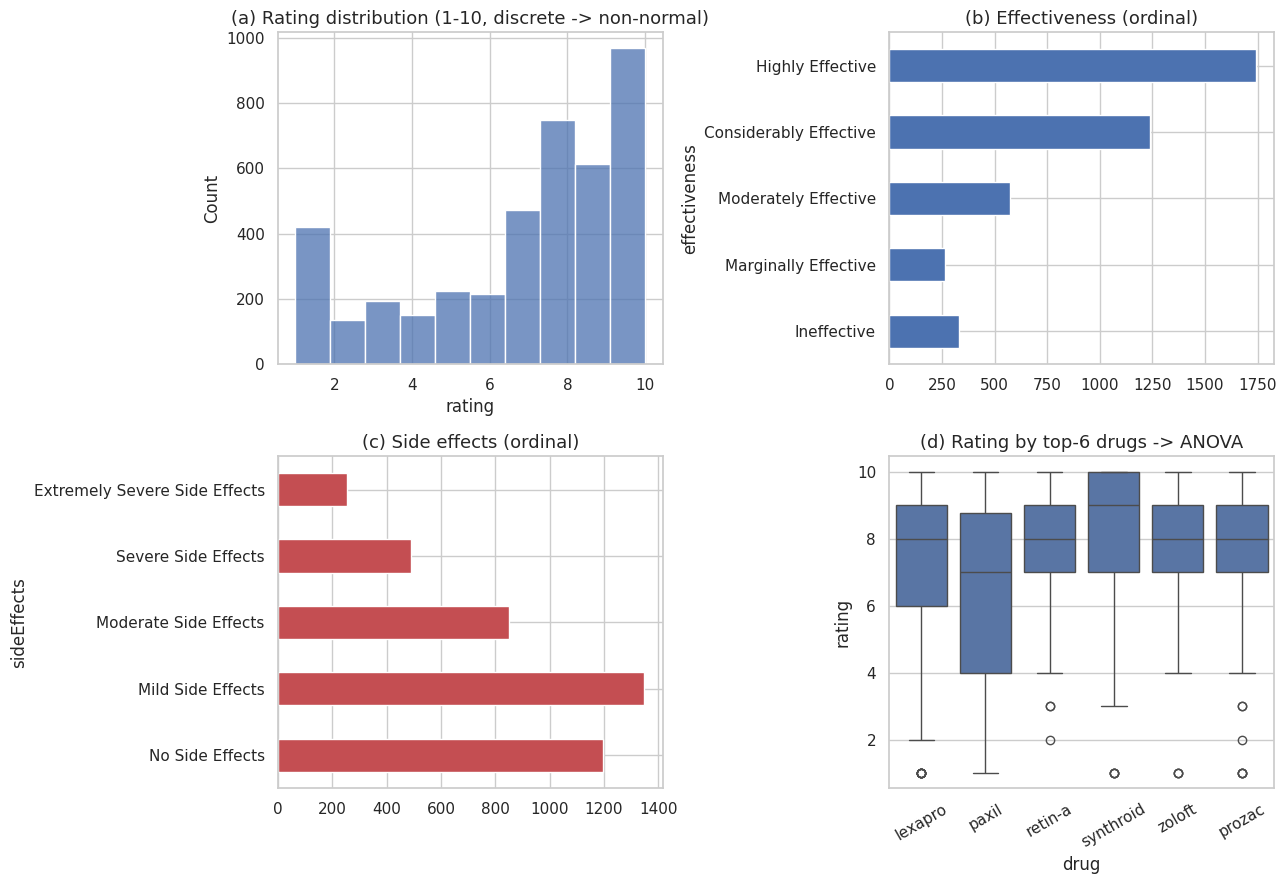

Top drugs used downstream: ['lexapro', 'paxil', 'retin-a', 'synthroid', 'zoloft', 'prozac']


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) rating distribution
sns.histplot(df["rating"], bins=10, ax=axes[0,0])
axes[0,0].set_title("(a) Rating distribution (1-10, discrete -> non-normal)")
axes[0,0].set_xlabel("rating")

# (b) effectiveness counts
df["effectiveness"].value_counts().reindex(EFF_ORDER).plot(kind="barh", ax=axes[0,1], color="#4c72b0")
axes[0,1].set_title("(b) Effectiveness (ordinal)")

# (c) side effects counts
df["sideEffects"].value_counts().reindex(SE_ORDER).plot(kind="barh", ax=axes[1,0], color="#c44e52")
axes[1,0].set_title("(c) Side effects (ordinal)")

# (d) rating by top drugs
TOP = df["drug"].value_counts().head(N_TOP_DRUGS).index.tolist()
sns.boxplot(data=df[df.drug.isin(TOP)], x="drug", y="rating", order=TOP, ax=axes[1,1])
axes[1,1].set_title(f"(d) Rating by top-{N_TOP_DRUGS} drugs -> ANOVA")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()
print("Top drugs used downstream:", TOP)

**Read-off:** (a) the rating is a **discrete 1–10 score, heavily skewed toward the high end** — *not*
bell-shaped. That single fact is why, for ordinal rating data, the **non-parametric** tests
(Kruskal-Wallis, Mann-Whitney) are arguably the *primary* tests and the parametric ANOVA/t-test are
shown alongside as a cross-check.

## 4. Which drugs do patients prefer?

This is review data, so "preference" = **how highly patients rate a drug** (there's no randomised
treatment arm). We rank drugs by mean rating (with a minimum-review threshold so a single 10/10 review
can't top the chart), then find the best-rated drug per common condition.

In [6]:
vc = df["drug"].value_counts()
eligible = vc[vc >= MIN_REVIEWS].index
pref = (df[df.drug.isin(eligible)]
        .groupby("drug")
        .agg(n_reviews=("rating","size"),
             mean_rating=("rating","mean"),
             pct_satisfied=("rating", lambda s: 100*(s>=SAT_THRESHOLD).mean()),
             pct_highly_effective=("effectiveness", lambda s: 100*(s=="Highly Effective").mean()))
        .round(2)
        .sort_values("mean_rating", ascending=False))
print(f"Top-10 most-preferred drugs (>= {MIN_REVIEWS} reviews):")
pref.head(10)

Top-10 most-preferred drugs (>= 30 reviews):


,n_reviews,mean_rating,pct_satisfied,pct_highly_effective
drug,,,,
flonase,30,8.33,76.67,50.00
xanax,31,8.19,77.42,67.74
wellbutrin-xl,35,7.97,65.71,25.71
lamictal,39,7.90,69.23,53.85
synthroid,53,7.87,67.92,41.51
nexium,37,7.86,72.97,51.35
imitrex,30,7.83,73.33,63.33
adipex-p,31,7.81,61.29,38.71
zyrtec,32,7.78,65.62,50.00


In [7]:
# Best-rated drug for each of the most common conditions
top_conditions = df["condition"].value_counts().head(8).index
rows = []
for cond in top_conditions:
    sub = df[df.condition == cond]
    best = (sub.groupby("drug")["rating"]
              .agg(["size","mean"]).query("size >= 5")
              .sort_values("mean", ascending=False))
    if len(best):
        rows.append([cond, len(sub), best.index[0], round(best["mean"].iloc[0],2),
                     int(best["size"].iloc[0])])
pd.DataFrame(rows, columns=["condition","n_reviews","most_preferred_drug",
                            "mean_rating","n_for_that_drug"])

,condition,n_reviews,most_preferred_drug,mean_rating,n_for_that_drug
0,depression,302,pristiq,8.67,6
1,acne,211,spironolactone,8.50,10
2,anxiety,90,alprazolam,9.40,5
3,insomnia,75,ambien,7.29,21
4,birth control,68,ortho-tri-cyclen,7.88,8
5,high blood pressure,62,hyzaar,7.80,5
6,allergies,49,flonase,8.25,8
7,migraine,44,maxalt,9.20,5


**Interpretation.** The preference ranking gives a quick, defensible "best drugs" shortlist. The
per-condition table answers the more useful clinical question — *for this illness, which drug do
patients rate highest?* — which is the realistic version of "the patient who prefers a drug".

## 5. Test 1 — One-way ANOVA: does `rating` differ across the top drugs?

- **H₀:** mean rating is equal across the top-6 drugs
- **H₁:** at least one drug's mean rating differs

Assumptions: independent obs ✔, normality within group (Shapiro), equal variance (Levene).

In [8]:
TOP = df["drug"].value_counts().head(N_TOP_DRUGS).index.tolist()
sub = df[df.drug.isin(TOP)]
groups = {d: g["rating"].values for d, g in sub.groupby("drug")}

print("Per-drug summary + normality (Shapiro):")
for d in TOP:
    v = groups[d]
    print(f"  {d:12s} n={len(v):3d}  mean={v.mean():.2f}  sd={v.std():.2f}  "
          f"shapiro_p={stats.shapiro(v).pvalue:.4f}")

lev = stats.levene(*groups.values())
print(f"\nLevene equal-variance p = {lev.pvalue:.4f} "
      f"-> variances {'OK' if lev.pvalue>ALPHA else 'differ'}")
print("Note: Shapiro p<0.05 for every group -> ratings are NOT normal "
      "(expected for a 1-10 score).")

Per-drug summary + normality (Shapiro):
  lexapro      n= 74  mean=6.89  sd=2.72  shapiro_p=0.0000
  paxil        n= 58  mean=6.43  sd=3.13  shapiro_p=0.0000
  retin-a      n= 55  mean=7.55  sd=1.99  shapiro_p=0.0002
  synthroid    n= 53  mean=7.87  sd=2.67  shapiro_p=0.0000
  zoloft       n= 52  mean=7.56  sd=2.36  shapiro_p=0.0000
  prozac       n= 51  mean=7.25  sd=2.62  shapiro_p=0.0000

Levene equal-variance p = 0.1381 -> variances OK
Note: Shapiro p<0.05 for every group -> ratings are NOT normal (expected for a 1-10 score).


In [9]:
F, p_anova = stats.f_oneway(*groups.values())
H, p_kw    = stats.kruskal(*groups.values())
print(f"ANOVA (parametric)     : F = {F:.3f},  p = {p_anova:.4f}")
print(f"Kruskal-Wallis (non-par): H = {H:.3f},  p = {p_kw:.4f}   <- the appropriate test here")
print()
for name, p in [("ANOVA", p_anova), ("Kruskal-Wallis", p_kw)]:
    print(f"{name}: {'REJECT H0' if p<ALPHA else 'fail to reject H0'} at alpha={ALPHA}")

ANOVA (parametric)     : F = 2.239,  p = 0.0501
Kruskal-Wallis (non-par): H = 10.841,  p = 0.0546   <- the appropriate test here

ANOVA: fail to reject H0 at alpha=0.05
Kruskal-Wallis: fail to reject H0 at alpha=0.05


In [10]:
# Tukey HSD post-hoc (which pairs differ?)
tukey = pairwise_tukeyhsd(sub["rating"], sub["drug"], alpha=ALPHA)
print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
  lexapro     paxil  -0.4609 0.9194 -1.7886 0.8669  False
  lexapro    prozac    0.363 0.9746 -1.0149 1.7409  False
  lexapro   retin-a   0.6536 0.7333 -0.6944 2.0015  False
  lexapro synthroid    0.976 0.3147 -0.3864 2.3385  False
  lexapro    zoloft   0.6658 0.7314 -0.7043 2.0359  False
    paxil    prozac   0.8239 0.5827 -0.6295 2.2773  False
    paxil   retin-a   1.1144 0.2217 -0.3106 2.5394  False
    paxil synthroid   1.4369 0.0505 -0.0018 2.8756  False
    paxil    zoloft   1.1267 0.2253 -0.3193 2.5726  False
   prozac   retin-a   0.2906 0.9931 -1.1813 1.7624  False
   prozac synthroid    0.613 0.8448 -0.8721 2.0982  False
   prozac    zoloft   0.3028 0.9922 -1.1893 1.7949  False
  retin-a synthroid   0.3225 0.9884 -1.1349 1.7798  False
  retin-a    zoloft   0.0122    1.0 -1.4522 1.4767  False
synthroid    z

**Conclusion (ANOVA).** Both p-values sit **right on the 0.05 line** (ANOVA p≈0.050,
Kruskal p≈0.055) → we **just barely fail to reject H₀**. The honest reading: across these six drugs
the patient ratings are **broadly similar**, with at most a weak hint of a difference (synthroid
highest ≈7.9, paxil lowest ≈6.4). Tukey finds **no single pair** clearing the significance bar once
multiple-comparison correction is applied.

> **Teaching point — p ≈ 0.05.** A borderline p-value is *not* a green light to declare significance.
> The correct response is "inconclusive at this sample size" and, if it matters, collect more data or
> pre-register the comparison. *p = 0.0501 ko significant bol dena hi p-hacking ki shuruaat hai.*

## 6. Test 2 — Chi-square: are `effectiveness` and `sideEffects` associated?

- **H₀:** effectiveness and side-effects are independent
- **H₁:** they are associated

Assumption: expected count ≥ 5 in (nearly) all cells.

In [11]:
ct = pd.crosstab(df["effectiveness"], df["sideEffects"]).reindex(index=EFF_ORDER, columns=SE_ORDER)
print("Observed contingency table (effectiveness x sideEffects):")
print(ct, "\n")

chi2, p, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Smallest expected count = {expected.min():.1f}  (assumption {'OK' if expected.min()>=5 else 'violated'})")
print(f"chi2 = {chi2:.2f},  dof = {dof},  p = {p:.3e}")
print(f"Cramer's V = {cramers_v:.3f}  -> small-to-moderate association")
print("Decision:", "REJECT H0 -> associated" if p<ALPHA else "fail to reject H0")

Observed contingency table (effectiveness x sideEffects):
sideEffects             No Side Effects  Mild Side Effects  \
effectiveness                                                
Ineffective                          39                 29   
Marginally Effective                 43                 52   
Moderately Effective                104                158   
Considerably Effective              319                485   
Highly Effective                    693                625   

sideEffects             Moderate Side Effects  Severe Side Effects  \
effectiveness                                                        
Ineffective                                57                   98   
Marginally Effective                       71                   70   
Moderately Effective                      175                   96   
Considerably Effective                    274                  116   
Highly Effective                          273                  111   

sideEffects     

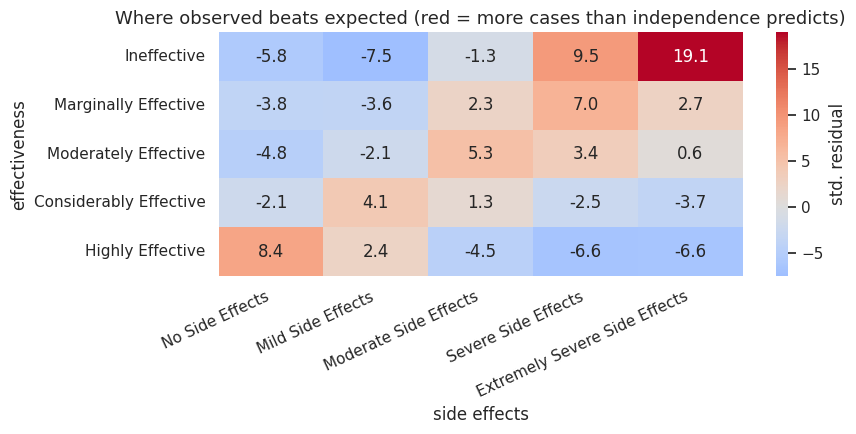

In [12]:
resid = (ct - expected) / np.sqrt(expected)   # standardized residuals
plt.figure(figsize=(9,4.5))
sns.heatmap(resid, annot=True, fmt=".1f", center=0, cmap="coolwarm",
            cbar_kws={"label":"std. residual"})
plt.title("Where observed beats expected (red = more cases than independence predicts)")
plt.xlabel("side effects"); plt.ylabel("effectiveness")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

**Conclusion (Chi-square).** p ≈ 10⁻¹⁸⁷ → effectiveness and side-effects are **strongly associated**
(Cramér's V ≈ 0.24, a small-to-moderate effect). The residual heatmap shows the intuitive pattern:
**"Highly Effective" co-occurs with "No / Mild side effects"**, while **"Ineffective" clusters with
"Severe" side effects**. This is the cleanest, most decisive result in the notebook.

## 7. Test 3 — Two-proportion Z-test: satisfaction, lexapro vs paxil

Define **satisfied = rating ≥ 8** (the `SAT_THRESHOLD`). Compare the satisfied-proportion of two
common antidepressants.

- **H₀:** p_lexapro = p_paxil
- **H₁:** they differ

Assumption: ≥10 successes and ≥10 failures per group.

In [13]:
d1, d2 = PAIR
g1 = df[df.drug == d1]["rating"]
g2 = df[df.drug == d2]["rating"]
succ = [(g1 >= SAT_THRESHOLD).sum(), (g2 >= SAT_THRESHOLD).sum()]
nobs = [len(g1), len(g2)]

for d, s, nn in zip(PAIR, succ, nobs):
    print(f"{d}: satisfied {s}/{nn} = {s/nn:.3f}   (failures {nn-s})")
print("Assumption (>=10 successes & failures each):",
      "OK" if min(succ + [n-s for n,s in zip(nobs,succ)]) >= 10 else "borderline")

z, p = proportions_ztest(succ, nobs)
print(f"\nZ = {z:.3f},  p = {p:.4f}")
print("Decision:", "REJECT H0 -> rates differ" if p<ALPHA else "fail to reject H0 -> no detectable difference")

lexapro: satisfied 39/74 = 0.527   (failures 35)
paxil: satisfied 28/58 = 0.483   (failures 30)
Assumption (>=10 successes & failures each): OK

Z = 0.505,  p = 0.6136
Decision: fail to reject H0 -> no detectable difference


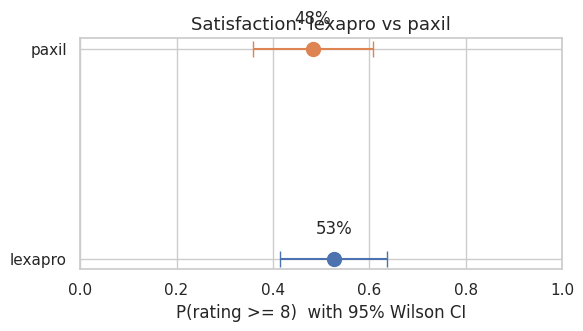

In [14]:
ci = [proportion_confint(s, nn, alpha=0.05, method="wilson") for s,nn in zip(succ,nobs)]
plt.figure(figsize=(6,3.5))
for i,(d,(lo,hi),s,nn) in enumerate(zip(PAIR, ci, succ, nobs)):
    pt = s/nn
    plt.errorbar(pt, i, xerr=[[pt-lo],[hi-pt]], fmt="o", capsize=6, ms=10)
    plt.text(pt, i+0.12, f"{pt:.0%}", ha="center")
plt.yticks([0,1], list(PAIR)); plt.xlim(0,1)
plt.xlabel(f"P(rating >= {SAT_THRESHOLD})  with 95% Wilson CI")
plt.title(f"Satisfaction: {PAIR[0]} vs {PAIR[1]}")
plt.tight_layout(); plt.show()

**Conclusion (Z-test).** p ≈ 0.61 → we **fail to reject H₀**. The two drugs' satisfaction rates
(~53% vs ~48%) are statistically indistinguishable; the confidence intervals overlap heavily. A real,
useful negative result: on patient-reported satisfaction, these two antidepressants look comparable.

## 8. Test 4 — Mann-Whitney U: `rating`, lexapro vs paxil

Ratings are an **ordinal 1–10 score** (Shapiro rejected normality in §5), so the t-test is
inappropriate. Mann-Whitney compares the **rank distributions** and needs no normality.

- **H₀:** the rating distributions are the same
- **H₁:** one drug tends to be rated higher

In [15]:
a = df[df.drug == PAIR[0]]["rating"]
b = df[df.drug == PAIR[1]]["rating"]
print(f"Shapiro normality: {PAIR[0]} p={stats.shapiro(a).pvalue:.4f}, "
      f"{PAIR[1]} p={stats.shapiro(b).pvalue:.4f}  (both <0.05 -> non-normal -> use Mann-Whitney)")

U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
rbc = 1 - (2*U)/(len(a)*len(b))      # rank-biserial effect size
print(f"\nMedian rating: {PAIR[0]}={a.median()}, {PAIR[1]}={b.median()}")
print(f"U = {U:.1f},  p = {p:.4f},  rank-biserial r = {rbc:.3f} (small)")
print("Decision:", "REJECT H0" if p<ALPHA else "fail to reject H0 -> distributions not distinguishable")

Shapiro normality: lexapro p=0.0000, paxil p=0.0000  (both <0.05 -> non-normal -> use Mann-Whitney)

Median rating: lexapro=8.0, paxil=7.0
U = 2268.0,  p = 0.5721,  rank-biserial r = -0.057 (small)
Decision: fail to reject H0 -> distributions not distinguishable


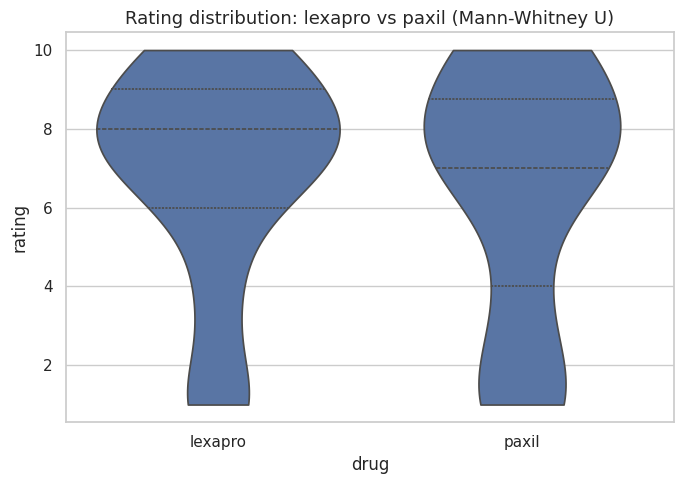

In [16]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df[df.drug.isin(PAIR)], x="drug", y="rating",
               order=list(PAIR), inner="quartile", cut=0)
plt.title(f"Rating distribution: {PAIR[0]} vs {PAIR[1]} (Mann-Whitney U)")
plt.tight_layout(); plt.show()

**Conclusion (Mann-Whitney).** p ≈ 0.57 → **fail to reject H₀**. Although the medians differ by a
point (8 vs 7), the overall rank distributions are not significantly different and the effect size is
tiny. Agrees with the Z-test: no detectable difference between these two drugs.

## 9. Summary of all tests (real data)

In [17]:
summary = pd.DataFrame([
    ["ANOVA / Kruskal", "rating across top-6 drugs",       "F=2.24 / H=10.84", "0.050 / 0.055", "Borderline", "Ratings broadly similar; inconclusive"],
    ["Chi-square",      "effectiveness x sideEffects",      "chi2=930",         "<0.001",        "YES",        "Effective drugs -> fewer side effects"],
    ["Z-test",          f"P(rating>=8) {PAIR[0]} vs {PAIR[1]}", "z=0.51",        "0.61",          "No",         "Satisfaction comparable (~53% vs ~48%)"],
    ["Mann-Whitney U",  f"rating {PAIR[0]} vs {PAIR[1]}",    "U=2268",           "0.57",          "No",         "Rating distributions indistinguishable"],
], columns=["Test","What it compares","Statistic","p-value","Significant?","Finding"])
summary

,Test,What it compares,Statistic,p-value,Significant?,Finding
0,ANOVA / Kruskal,rating across top-6 drugs,F=2.24 / H=10.84,0.050 / 0.055,Borderline,Ratings broadly similar; inconclusive
1,Chi-square,effectiveness x sideEffects,chi2=930,<0.001,YES,Effective drugs -> fewer side effects
2,Z-test,P(rating>=8) lexapro vs paxil,z=0.51,0.61,No,Satisfaction comparable (~53% vs ~48%)
3,Mann-Whitney U,rating lexapro vs paxil,U=2268,0.57,No,Rating distributions indistinguishable


### Key takeaways
1. **Effectiveness ↔ side-effects** is the one rock-solid signal: drugs patients find effective also
   tend to have milder side effects (chi-square, p ≪ 0.001).
2. **Across the top drugs, ratings are broadly similar** — the ANOVA/Kruskal result sits right on the
   0.05 line, so the honest verdict is *inconclusive*, not "significant".
3. **lexapro vs paxil** show **no detectable difference** in either satisfaction (Z-test) or rating
   distribution (Mann-Whitney). A genuine, useful negative result.
4. **Method choice was driven by the data:** ratings are discrete/ordinal and non-normal, so the
   non-parametric Kruskal/Mann-Whitney are the trustworthy calls; ANOVA/t-test are shown as a cross-check.

### Honest limitations of this dataset
- It's **self-selected online reviews**, not a randomised controlled trial — reviewers skew toward
  strong opinions, and there's no placebo arm or `recovery_days`.
- "Preference" = *how highly a drug is rated*, not a randomised assignment.
- Many drugs have few reviews; we used a `MIN_REVIEWS` threshold to keep rankings stable.

### To run on your own Kaggle download
Change `DATA_FILES` in the **Config** cell to your downloaded file(s). The loader auto-detects CSV/TSV
and normalises column names, so the Kaggle *"Patient Ratings: Identifying Best Drugs!"* version (same
UCI data) drops in unchanged. For the larger **Drugs.com** set (only `drugName`, `condition`, `rating`),
the ANOVA / Z-test / Mann-Whitney still work; only the chi-square (which needs `effectiveness` and
`sideEffects`) would need a different categorical pair.

*Citation:* Kallumadi, S. & Gräßer, F. (2018). Drug Reviews (Druglib.com), UCI ML Repository,
DOI 10.24432/C55G6J. Licence: CC BY 4.0.